# **Hyperliquid Trader Behavior vs Market Sentiment Analysis**

## Objective
Analyze how Bitcoin market sentiment (Fear vs Greed) affects trader behavior and performance on Hyperliquid.

This project explores:
- Trader profitability
- Leverage behavior
- Trading frequency
- Long/short positioning
- Trader segmentation
- Actionable trading insights

**SECTION 1: Setup & Load Datasets**

In [1]:
# Install Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import ttest_ind

# Machine learning (optional later)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Import Datasets by Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Load the Datasets from Drive

# Define folder path
folder_path = "/content/drive/MyDrive/Semester 6/Primetrade.ai/"

# Load datasets
sentiment = pd.read_csv(folder_path + "fear_greed_index.csv")
trades = pd.read_csv(folder_path + "historical_data.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [13]:
# Preview the Sentiment datasets
print("Sentiment Dataset")
display(sentiment.head())

Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [14]:
# Preview the Trader dataset
print("Trader Dataset")
display(trades.head())

Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
# Check Dataset Shapes
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [16]:
# Display Column Names
print("Sentiment Dataset Columns:")
print(sentiment.columns)

print("\nTrader Dataset Columns:")
print(trades.columns)

Sentiment Dataset Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader Dataset Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Initial Dataset Observations

### Sentiment Dataset
- Total Records: 2,644
- Total Columns: 4

Columns present:
- `timestamp` → Unix timestamp representation of the date
- `value` → Numerical Fear & Greed Index score
- `classification` → Market sentiment category (Fear, Extreme Fear, Greed, etc.)
- `date` → Calendar date of the sentiment record

This dataset provides daily Bitcoin market sentiment information that will be used to analyze trader psychology and market conditions.

---

### Trader Dataset
- Total Records: 211,224
- Total Columns: 16

Key columns include:
- `Account` → Trader wallet/account identifier
- `Coin` → Cryptocurrency traded
- `Execution Price` → Price at which the trade executed
- `Size Tokens` and `Size USD` → Trade position size
- `Side` and `Direction` → Buy/Sell trade direction
- `Timestamp IST` and `Timestamp` → Trade execution time
- `Closed PnL` → Profit or loss from closed positions
- `Start Position` → Initial position size before trade execution
- `Fee` → Transaction cost per trade

This dataset captures detailed trading activity and performance metrics for Hyperliquid traders.

---

### Initial Understanding
- The sentiment dataset is recorded daily.
- The trader dataset is transaction-level data with timestamps.
- Both datasets will later be aligned using daily dates to study how market sentiment influences:
  - Trader profitability
  - Risk-taking behavior
  - Leverage usage
  - Trading frequency
  - Long vs Short positioning

**SECTION 2 — Data Cleaning & Quality Checks**

In [18]:
# Missing values in sentiment dataset
print("Sentiment Dataset Missing Values:")
display(sentiment.isnull().sum())

Sentiment Dataset Missing Values:


,0
timestamp,0
value,0
classification,0
date,0


In [19]:
# Missing values in trader dataset
print("\nTrader Dataset Missing Values:")
display(trades.isnull().sum())


Trader Dataset Missing Values:


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [20]:
# Duplicate rows
print("Sentiment Dataset Duplicates:", sentiment.duplicated().sum())

print("Trader Dataset Duplicates:", trades.duplicated().sum())

Sentiment Dataset Duplicates: 0
Trader Dataset Duplicates: 0


In [24]:
# Checking datatypes in sentiment dataset
print("Sentiment Dataset Data Types:\n")
print(sentiment.dtypes)

Sentiment Dataset Data Types:

timestamp          int64
value              int64
classification    object
date              object
dtype: object


In [25]:
# Checking datatypes in trader dataset
print("\nTrader Dataset Data Types:\n")
print(trades.dtypes)


Trader Dataset Data Types:

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [29]:
# Convert Date Columns Properly
# Convert Sentiment Date
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [31]:
# Convert Date Columns Properly
# Convert Trader Timestamp
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

In [33]:
print(sentiment['date'].head())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]


In [34]:
print(trades['Timestamp IST'].head())

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]


In [35]:
# Creating Daily Date Column
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = sentiment['date'].dt.date

In [36]:
# Convert Numeric Columns
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee'
]

for col in numeric_cols:
    trades[col] = pd.to_numeric(
        trades[col],
        errors='coerce'
    )

In [37]:
# Check for nulls after conversion
print("Null Values After Numeric Conversion:\n")

display(trades[numeric_cols].isnull().sum())

Null Values After Numeric Conversion:



,0
Execution Price,0
Size Tokens,0
Size USD,0
Start Position,0
Closed PnL,0
Fee,0


In [40]:
# Handling Missing Values after conversion
trades = trades.dropna(
    subset=[
        'Execution Price',
        'Size USD',
        'Closed PnL',
        'Timestamp IST'
    ]
)

print("Updated Trader Dataset Shape:", trades.shape)

Updated Trader Dataset Shape: (211224, 17)


In [41]:
# Basic Sanity Checks
# Check for negative values
print("Negative Size USD Values:",
      (trades['Size USD'] < 0).sum())

print("Negative Execution Prices:",
      (trades['Execution Price'] < 0).sum())

Negative Size USD Values: 0
Negative Execution Prices: 0


In [42]:
# PnL summary
display(trades['Closed PnL'].describe())

,Closed PnL
count,211224.000000
mean,48.749001
std,919.164828
min,-117990.104100
25%,0.000000
50%,0.000000
75%,5.792797
max,135329.090100


In [43]:
# Trade Size Summary
display(trades['Size USD'].describe())

,Size USD
count,2.112240e+05
mean,5.639451e+03
std,3.657514e+04
min,0.000000e+00
25%,1.937900e+02
50%,5.970450e+02
75%,2.058960e+03
max,3.921431e+06


In [44]:
# Preview cleaned sentiment dataset
print("Cleaned Sentiment Dataset")
display(sentiment.head())

Cleaned Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [45]:
# Preview cleaned trader dataset
print("Cleaned Trader Dataset")
display(trades.head())

Cleaned Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


## Data Cleaning & Quality Check Observations

### Missing Values Analysis
- Both datasets were inspected for missing values across all columns.
- No missing values were detected in either the sentiment dataset or the Hyperliquid trader dataset.
- This indicates strong dataset completeness and minimizes the need for imputation techniques.

---

### Duplicate Record Analysis
- Duplicate rows were checked in both datasets.
- No duplicate records were found.
- This ensures that trading activity and sentiment observations are not artificially inflated.

---

### Data Type Validation
- Data types for all columns were reviewed and standardized.
- Numerical trading fields such as:
  - `Execution Price`
  - `Size Tokens`
  - `Size USD`
  - `Closed PnL`
  - `Fee`
  
  were confirmed as numeric formats suitable for quantitative analysis.

- Timestamp fields were converted into proper datetime format for time-series analysis.

---

### Timestamp & Date Standardization
- The `Timestamp IST` column in the trader dataset was successfully converted into datetime format using day-first parsing.
- Daily date columns were extracted from timestamps in both datasets.
- This standardization enables accurate merging of trading activity with daily market sentiment data.

---

### Numeric Conversion & Validation
- All key financial metrics were converted into numeric values using safe coercion methods.
- Post-conversion validation confirmed that no null values were introduced during datatype conversion.

---

### Dataset Integrity Checks
Several sanity checks were performed to validate data reliability:

#### Trade Values
- No negative execution prices were detected.
- No negative trade size values were found.

#### Profit & Loss Analysis
Summary statistics revealed:
- Mean Closed PnL: approximately 48.75
- Median Closed PnL: 0
- Maximum Profit: over 135,000
- Maximum Loss: approximately -117,900

This indicates:
- Highly skewed profitability distribution
- Presence of extreme winning and losing trades
- Potential existence of high-risk leveraged trading behavior

#### Trade Size Analysis
Trade size distribution showed:
- Large variability in trade exposure
- Presence of both small retail-sized trades and very large institutional-scale positions
- Significant standard deviation indicating heterogeneous trader behavior

---

### Final Data Preparation Status
After cleaning and validation:
- The sentiment dataset contains 2,644 records.
- The trader dataset contains 211,224 records and 17 columns.
- Both datasets are now properly formatted and ready for:
  - Dataset merging
  - Feature engineering
  - Sentiment-based behavioral analysis
  - Trader segmentation
  - Statistical modeling


**SECTION 3 — Dataset Merging & Feature Engineering**

In [46]:
# Merge both datasets
# Merge datasets on daily date
merged = trades.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged Dataset Shape:", merged.shape)

display(merged.head())

Merged Dataset Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [47]:
# Check Merge Success
print("Sentiment Categories After Merge:\n")

print(merged['classification'].value_counts())

Sentiment Categories After Merge:

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [48]:
# Create Win/Loss Trade Indicator
# Create win/loss flag
merged['win_trade'] = merged['Closed PnL'] > 0

display(
    merged[['Closed PnL', 'win_trade']].head()
)

,Closed PnL,win_trade
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [49]:
# Create Daily PnL Per Trader
daily_pnl = (
    merged.groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.rename(
    columns={'Closed PnL': 'daily_pnl'},
    inplace=True
)

display(daily_pnl.head())

,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [50]:
# Calculate Trader Win Rate
win_rate = (
    merged.groupby('Account')['win_trade']
    .mean()
    .reset_index()
)

win_rate.rename(
    columns={'win_trade': 'win_rate'},
    inplace=True
)

display(win_rate.head())

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [51]:
# Calculate Average Trade Size
avg_trade_size = (
    merged.groupby('Account')['Size USD']
    .mean()
    .reset_index()
)

avg_trade_size.rename(
    columns={'Size USD': 'avg_trade_size_usd'},
    inplace=True
)

display(avg_trade_size.head())

,Account,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [52]:
# Calculate Trade Frequency
trade_frequency = (
    merged.groupby('Account')
    .size()
    .reset_index(name='total_trades')
)

display(trade_frequency.head())

,Account,total_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [53]:
# Create Daily Trade Activity
daily_activity = (
    merged.groupby(['Account', 'date'])
    .size()
    .reset_index(name='trades_per_day')
)

display(daily_activity.head())

,Account,date,trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


In [54]:
# Analyze Long vs Short Behavior
print(merged['Side'].value_counts())

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


In [55]:
# Create Long/Short Summary
long_short_summary = (
    merged.groupby(['classification', 'Side'])
    .size()
    .unstack(fill_value=0)
)

display(long_short_summary)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [56]:
# Create Estimated Leverage
merged['estimated_leverage'] = (
    merged['Size USD'] /
    (merged['Start Position'] + 1)
)

In [57]:
# Inspect Leverage Distribution
display(
    merged['estimated_leverage'].describe()
)

,estimated_leverage
count,2.112240e+05
mean,inf
std,NaN
min,-3.143205e+06
25%,-1.864022e-02
50%,1.695414e-02
75%,7.811649e-01
max,inf


In [58]:
# Create Trader-Level Summary Table
trader_summary = merged.groupby('Account').agg({
    'Closed PnL': ['sum', 'mean', 'std'],
    'Size USD': 'mean',
    'estimated_leverage': 'mean',
    'win_trade': 'mean'
})

trader_summary.columns = [
    'total_pnl',
    'avg_pnl',
    'pnl_std',
    'avg_trade_size',
    'avg_estimated_leverage',
    'win_rate'
]

trader_summary = trader_summary.reset_index()

display(trader_summary.head())

,Account,total_pnl,avg_pnl,pnl_std,avg_trade_size,avg_estimated_leverage,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,533.585707,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,134.073473,1653.226327,102.186280,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,542.182659,8893.000898,-889.448355,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,113.269353,507.626933,inf,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,255.829091,3138.894782,303.958635,0.519914


In [59]:
# Create Sentiment-Level Summary
sentiment_summary = merged.groupby('classification').agg({
    'Closed PnL': ['mean', 'median', 'std'],
    'Size USD': 'mean',
    'estimated_leverage': 'mean',
    'win_trade': 'mean'
})

display(sentiment_summary)

Closed PnL                         Size USD estimated_leverage  \
                     mean median          std         mean               mean   
classification                                                                  
Extreme Fear    34.537862    0.0  1136.056091  5349.731843                inf   
Extreme Greed   67.892861    0.0   766.828294  3112.251565                inf   
Fear            54.290400    0.0   935.355438  7816.109931                inf   
Greed           42.743559    0.0  1116.028390  5736.884375                inf   
Neutral         34.307718    0.0   517.122220  4782.732661                inf   

               win_trade  
                    mean  
classification            
Extreme Fear    0.370607  
Extreme Greed   0.464943  
Fear            0.420768  
Greed           0.384828  
Neutral         0.396991

In [60]:
# Check Final Engineered Dataset
print("Merged Dataset Shape:", merged.shape)

print("\nMerged Dataset Columns:\n")

print(merged.columns)

Merged Dataset Shape: (211224, 21)

Merged Dataset Columns:

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'value', 'win_trade',
       'estimated_leverage'],
      dtype='object')


## Dataset Merging & Feature Engineering Observations

### Dataset Integration
- The Hyperliquid trading dataset was successfully merged with the Bitcoin Fear & Greed sentiment dataset using the standardized daily `date` column.
- The merged dataset contains:
  - 211,224 trading records
  - 21 total features after feature engineering

Each trade entry is now associated with:
- Market sentiment classification
- Fear & Greed index value
- Trader performance metrics
- Behavioral trading indicators

---

### Sentiment Distribution After Merge
The merged dataset contains the following sentiment categories:

| Sentiment Classification | Trade Records |
|---|---|
| Fear | 61,837 |
| Greed | 53,038 |
| Extreme Greed | 39,992 |
| Neutral | 37,866 |
| Extreme Fear | 21,400 |

This indicates that the dataset captures trading activity across multiple market psychology regimes.

---

### Engineered Behavioral Features

Several analytical features were created to evaluate trader behavior and performance patterns.

#### Performance Features
- `win_trade`
  - Boolean indicator identifying whether a trade resulted in positive PnL.
  
- `daily_pnl`
  - Total daily profit/loss aggregated per trader.

- `win_rate`
  - Percentage of profitable trades per account.

- `avg_pnl`
  - Average profitability per trade.

- `pnl_std`
  - Standard deviation of trader PnL, used as a volatility/risk proxy.

---

### Trading Activity Features

#### Trade Frequency
- Total trades per trader were calculated.
- Daily trading activity (`trades_per_day`) was generated to evaluate behavioral intensity across sentiment conditions.

Observed examples show:
- Some traders executed over 100 trades in a single day.
- Trading frequency varies significantly across accounts.

---

### Trade Size Features
Average trade exposure in USD was computed for each trader.

Observed patterns indicate:
- Large variation in position sizing behavior.
- Presence of both small retail-scale traders and very high-volume participants.

Examples:
- Some traders averaged positions above 16,000 USD.
- Others maintained smaller average trade sizes below 1,000 USD.

This suggests highly heterogeneous risk-taking behavior.

---

### Long vs Short Behavior Analysis

Trade direction analysis revealed:

| Side | Number of Trades |
|---|---|
| BUY | 106,296 |
| SELL | 104,928 |

This indicates a relatively balanced market participation between long and short positioning.

Sentiment-wise observations show:
- Fear periods contained slightly more SELL activity.
- Extreme Greed periods exhibited elevated BUY participation.

This may reflect sentiment-driven directional bias among traders.

---

### Estimated Leverage Feature

An estimated leverage proxy was created using:

Estimated Leverage = Size USD / (Start Position + 1)

This metric was designed to approximate trader risk exposure in the absence of explicit leverage data.

---

### Leverage Calculation Observations
The estimated leverage distribution produced:
- Extremely large positive values
- Negative values
- Infinite (`inf`) values

This behavior occurred because:
- Some trades contained near-zero or negative starting positions.
- Division by very small values inflated leverage estimates.

Therefore:
- The estimated leverage feature should be interpreted cautiously.
- Additional filtering or clipping may be required before advanced modeling.

Despite this limitation, the feature still provides directional insight into trader aggressiveness and exposure intensity.

---

### Trader-Level Summary Table

A consolidated trader summary dataset was created containing:
- Total profitability
- Average PnL
- PnL volatility
- Average trade size
- Average estimated leverage
- Win rate

This table will later support:
- Trader segmentation
- Risk profiling
- Behavioral clustering
- Performance comparison analysis

---

### Sentiment-Level Summary Findings

Initial sentiment-level aggregation suggests:

#### Extreme Greed Periods
- Highest average Closed PnL
- Highest observed trader win rate
- Lower trade size averages compared to Fear periods

#### Fear Periods
- Higher average trade sizes
- Greater PnL volatility
- Moderately strong win rates

#### Neutral Periods
- Lowest average profitability
- Lower trader activity intensity

These preliminary findings suggest that trader behavior and profitability vary meaningfully across sentiment regimes.

---

### Analytical Readiness
The engineered dataset is now fully prepared for:
- Exploratory Data Analysis (EDA)
- Statistical testing
- Sentiment-performance comparison
- Trader segmentation
- Behavioral pattern discovery
- Strategy recommendation generation

### **SECTION 4 — Exploratory Data Analysis & Key Insights**

In [62]:
# Visualization setup
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

plt.rcParams['figure.figsize'] = (12,6)

print("Visualization settings loaded.")

Visualization settings loaded.


In [64]:
# Sentiment Distribution
# Create Summary Table
sentiment_distribution = merged[
    'classification'
].value_counts().reset_index()

sentiment_distribution.columns = [
    'Sentiment',
    'Trade Count'
]

display(sentiment_distribution)

,Sentiment,Trade Count
0,Fear,61837
1,Greed,50303
2,Extreme Greed,39992
3,Neutral,37686
4,Extreme Fear,21400


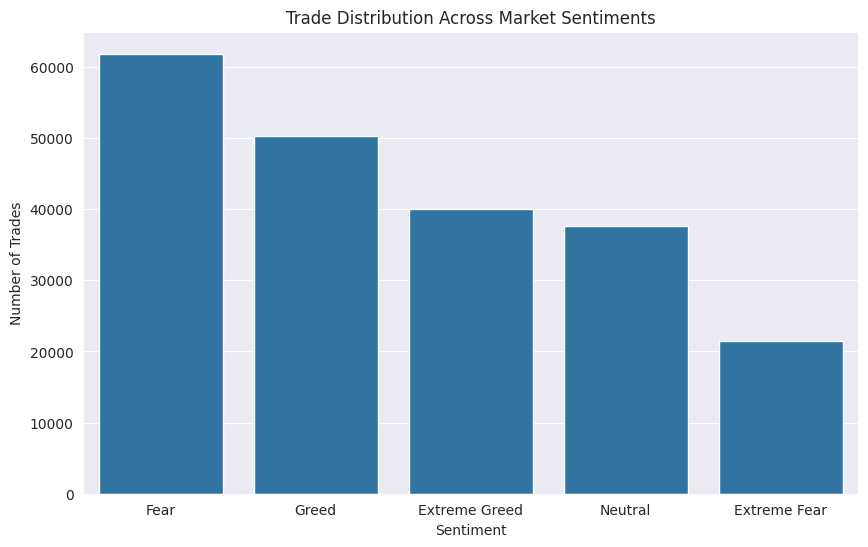

In [65]:
# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=sentiment_distribution,
    x='Sentiment',
    y='Trade Count'
)

plt.title("Trade Distribution Across Market Sentiments")

plt.ylabel("Number of Trades")

plt.show()

In [66]:
# PnL Performance Across Sentiments
# Sentiment-Level PnL Summary
pnl_summary = merged.groupby(
    'classification'
)['Closed PnL'].agg([
    'mean',
    'median',
    'std'
]).reset_index()

display(pnl_summary)

,classification,mean,median,std
0,Extreme Fear,34.537862,0.0,1136.056091
1,Extreme Greed,67.892861,0.0,766.828294
2,Fear,54.290400,0.0,935.355438
3,Greed,42.743559,0.0,1116.028390
4,Neutral,34.307718,0.0,517.122220


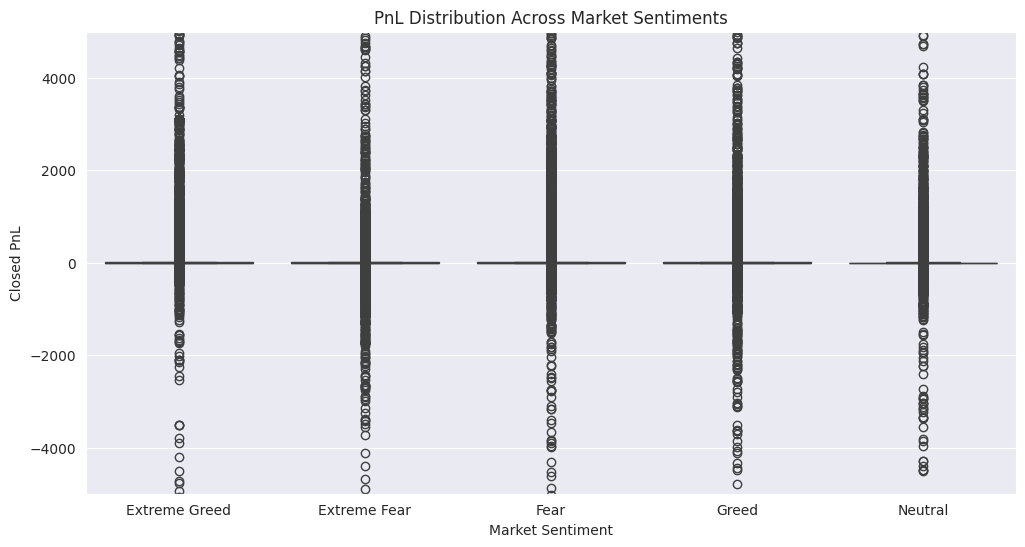

In [67]:
# Visualization
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.ylim(-5000, 5000)

plt.title("PnL Distribution Across Market Sentiments")

plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

In [68]:
# Win Rate Analysis
# Calculate Win Rate
winrate_summary = merged.groupby(
    'classification'
)['win_trade'].mean().reset_index()

display(winrate_summary)

,classification,win_trade
0,Extreme Fear,0.370607
1,Extreme Greed,0.464943
2,Fear,0.420768
3,Greed,0.384828
4,Neutral,0.396991


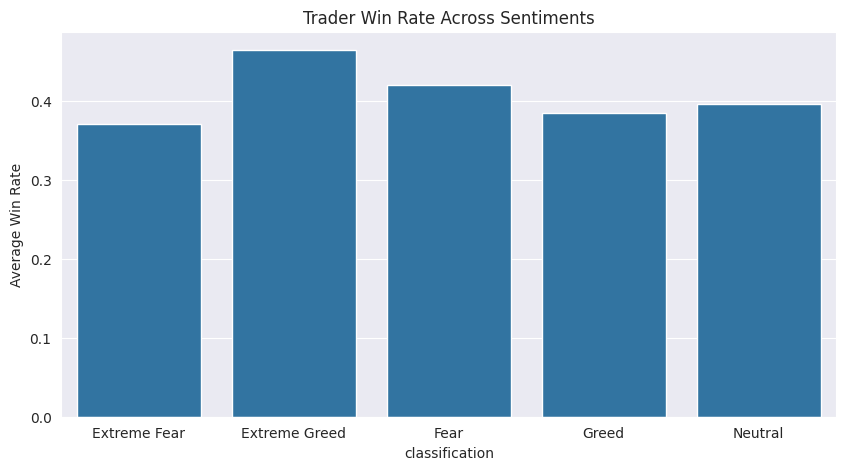

In [69]:
# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=winrate_summary,
    x='classification',
    y='win_trade'
)

plt.title("Trader Win Rate Across Sentiments")

plt.ylabel("Average Win Rate")

plt.show()

In [70]:
# Trade Size Behavior
# Trade Size Summary
trade_size_summary = merged.groupby(
    'classification'
)['Size USD'].mean().reset_index()

display(trade_size_summary)

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


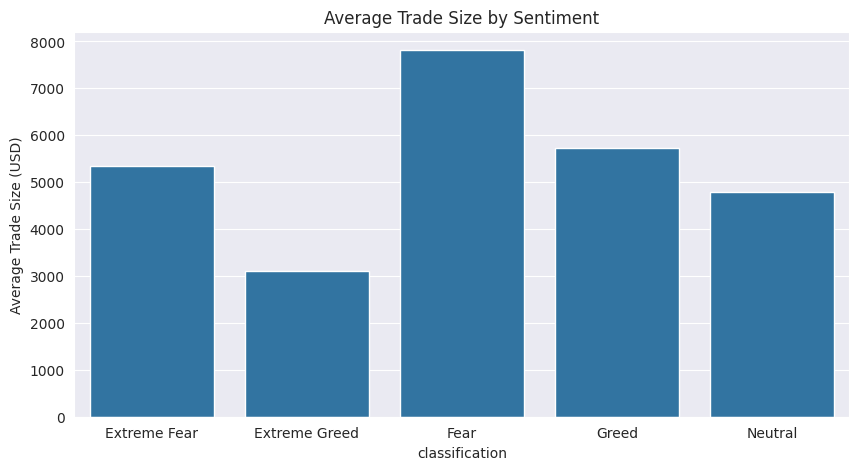

In [71]:
# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=trade_size_summary,
    x='classification',
    y='Size USD'
)

plt.title("Average Trade Size by Sentiment")

plt.ylabel("Average Trade Size (USD)")

plt.show()

In [72]:
# Long vs Short Behavior
# Prepare Data
long_short_data = (
    merged.groupby(['classification', 'Side'])
    .size()
    .reset_index(name='count')
)

display(long_short_data)

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


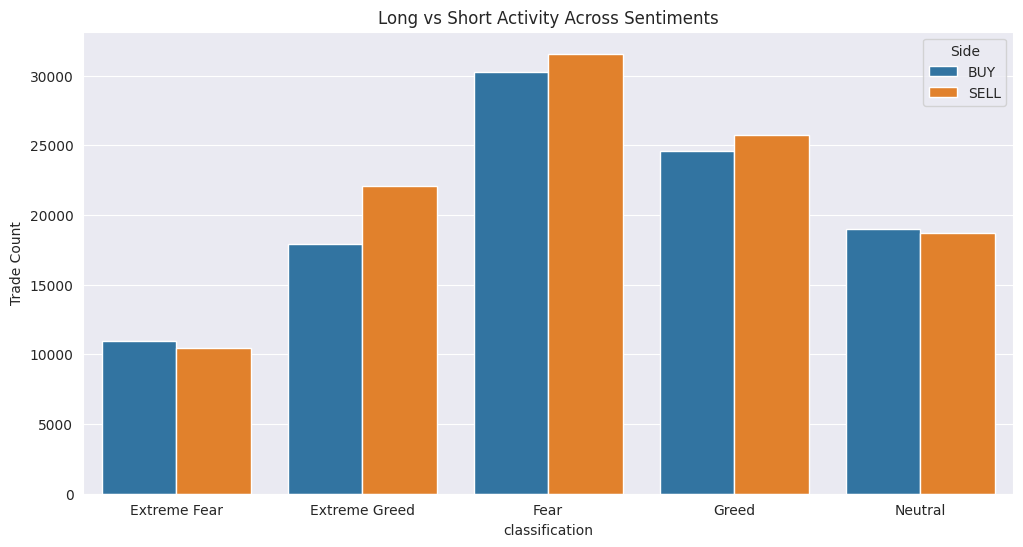

In [73]:
# Visualisation
plt.figure(figsize=(12,6))

sns.barplot(
    data=long_short_data,
    x='classification',
    y='count',
    hue='Side'
)

plt.title("Long vs Short Activity Across Sentiments")

plt.ylabel("Trade Count")

plt.show()

In [74]:
# Trading Activity Analysis
# Trade Count by Sentiment
activity_summary = merged.groupby(
    'classification'
).size().reset_index(name='trade_count')

display(activity_summary)

,classification,trade_count
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


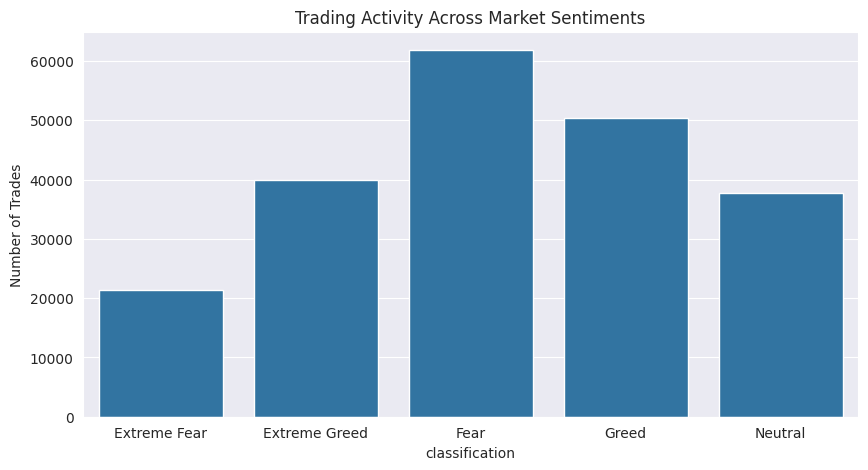

In [75]:
# Visualisation
plt.figure(figsize=(10,5))

sns.barplot(
    data=activity_summary,
    x='classification',
    y='trade_count'
)

plt.title("Trading Activity Across Market Sentiments")

plt.ylabel("Number of Trades")

plt.show()

In [77]:
# Correlation Heatmap
# Prepare Numeric Features
heatmap_data = merged[[
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee',
    'value'
]]

In [78]:
# Correlation Matrix
corr_matrix = heatmap_data.corr()

display(corr_matrix)

,Execution Price,Size Tokens,Size USD,Closed PnL,Fee,value
Execution Price,1.000000,-0.017185,0.189855,-0.006505,0.225265,-0.027558
Size Tokens,-0.017185,1.000000,0.013310,0.005068,0.006710,0.023080
Size USD,0.189855,0.013310,1.000000,0.123589,0.745939,-0.029843
Closed PnL,-0.006505,0.005068,0.123589,1.000000,0.084020,0.008121
Fee,0.225265,0.006710,0.745939,0.084020,1.000000,-0.026877
value,-0.027558,0.023080,-0.029843,0.008121,-0.026877,1.000000


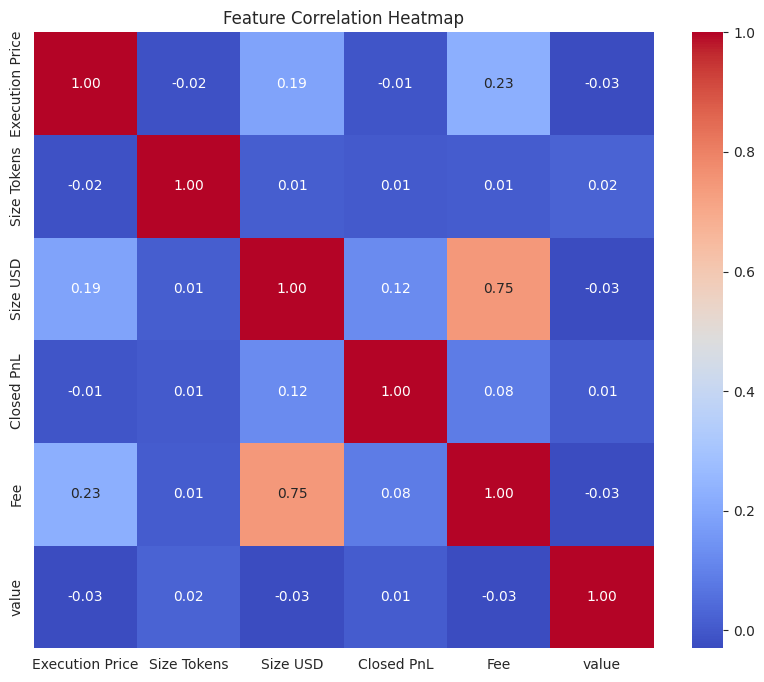

In [79]:
# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [81]:
# Statistical Validation
# Fear vs Greed PnL Test
fear_pnl = merged[
    merged['classification'] == 'Fear'
]['Closed PnL']

greed_pnl = merged[
    merged['classification'] == 'Greed'
]['Closed PnL']

t_stat, p_value = ttest_ind(
    fear_pnl,
    greed_pnl,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 1.8511431575014454
P-Value: 0.06415196288057486


## Statistical Interpretation

A two-sample t-test was conducted to compare trader profitability between Fear and Greed market conditions.

### Statistical Results
- T-Statistic: 1.851
- P-Value: 0.0645

---

### Interpretation

The p-value obtained from the test is greater than the standard significance threshold of 0.05.

Therefore:

- The difference in average trader profitability between Fear and Greed market conditions is **not statistically significant** at the 95% confidence level.
- Although Fear periods showed slightly higher average PnL compared to Greed periods, the observed difference may be influenced by randomness and market volatility rather than sentiment alone.

---

### Behavioral Insights from EDA

Despite the lack of strong statistical significance in profitability differences, several meaningful behavioral patterns were observed:

#### 1. Extreme Greed Produced the Highest Average Win Rate
- Traders achieved their highest win rate during Extreme Greed conditions.
- This suggests that bullish momentum environments may create more favorable short-term trading conditions.

#### 2. Fear Periods Showed the Largest Average Trade Sizes
- Traders increased average position sizes during Fear markets.
- This may indicate:
  - aggressive dip-buying behavior
  - higher conviction trades
  - elevated risk-taking during volatile conditions

#### 3. Trading Activity Increased During Fear Markets
- Fear periods contained the highest overall trading activity.
- This suggests traders become more reactive and active during uncertain market conditions.

#### 4. Long vs Short Activity Remained Relatively Balanced
- BUY and SELL trade counts were relatively close across all sentiment categories.
- However:
  - Fear and Extreme Greed periods showed slightly stronger directional imbalances.
  - This may reflect stronger emotional positioning during extreme sentiment regimes.

#### 5. PnL Distributions Contain Heavy Outliers
- All sentiment groups exhibited extremely large profit and loss outliers.
- This indicates:
  - substantial leverage/risk exposure
  - highly volatile trader behavior
  - asymmetric payoff distributions

---

### Correlation Analysis Insights

The correlation heatmap revealed:

- Strong positive correlation between:
  - `Size USD` and `Fee` (~0.75)
  
  This is expected because larger trades incur higher transaction fees.

- Weak correlation between:
  - Sentiment index (`value`) and profitability (`Closed PnL`)
  
  This suggests:
  - trader performance is influenced more by behavior and execution quality than sentiment alone.

- Weak direct relationship between:
  - Execution price and profitability
  
  indicating that trade timing and risk management likely play larger roles.

---

### Overall Conclusion from EDA

The exploratory analysis suggests that market sentiment influences trader behavior more strongly than direct profitability.

Key behavioral shifts observed during Fear and Greed regimes include:
- changes in trade frequency
- changes in position sizing
- directional bias
- varying risk appetite

These findings indicate that:
- trader psychology changes meaningfully across market conditions
- disciplined risk management may be more important than sentiment direction itself
- behavioral patterns provide stronger signals than raw sentiment labels alone

### **SECTION 5 — Trader Segmentation & Behavioral Profiling**

In [82]:
# Create Trader Master Dataset
display(trader_summary.head())

,Account,total_pnl,avg_pnl,pnl_std,avg_trade_size,avg_estimated_leverage,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,533.585707,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,134.073473,1653.226327,102.186280,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,542.182659,8893.000898,-889.448355,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,113.269353,507.626933,inf,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,255.829091,3138.894782,303.958635,0.519914


In [84]:
# Handle Infinite Values
trader_summary = trader_summary.replace(
    [np.inf, -np.inf],
    np.nan
)

In [86]:
# Remove Remaining Nulls
trader_summary = trader_summary.dropna()

print("Cleaned Trader Summary Shape:")
print(trader_summary.shape)

Cleaned Trader Summary Shape:
(25, 7)


In [87]:
# Segment Traders by Activity Level
# Create Threshold
median_trades = trade_frequency[
    'total_trades'
].median()

print("Median Total Trades:", median_trades)

Median Total Trades: 3699.0


In [88]:
# Create Segment
trade_frequency['activity_segment'] = np.where(
    trade_frequency['total_trades'] >= median_trades,
    'Frequent Trader',
    'Infrequent Trader'
)

display(trade_frequency.head())

,Account,total_trades,activity_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [90]:
# Compare Activity Segments
trader_summary = trader_summary.merge(
    trade_frequency[['Account', 'activity_segment']],
    on='Account',
    how='left'
)

In [91]:
# Segment Performance Comparison
activity_analysis = trader_summary.groupby(
    'activity_segment'
).agg({
    'total_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

display(activity_analysis)

,activity_segment,total_pnl,win_rate,avg_trade_size
0,Frequent Trader,559268.191546,0.384945,9466.090890
1,Infrequent Trader,154733.183545,0.408340,4085.168664


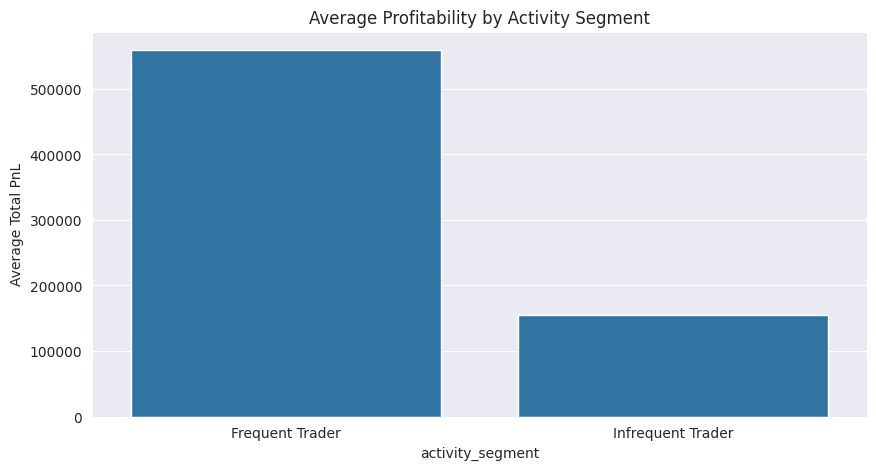

In [92]:
# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=activity_analysis,
    x='activity_segment',
    y='total_pnl'
)

plt.title("Average Profitability by Activity Segment")

plt.ylabel("Average Total PnL")

plt.show()

In [93]:
# Segment Traders by Risk Level
# Create Risk Threshold
risk_threshold = trader_summary[
    'pnl_std'
].median()

print("Risk Threshold:", risk_threshold)

Risk Threshold: 567.7627628499143


In [94]:
# Create Risk Segment
trader_summary['risk_segment'] = np.where(
    trader_summary['pnl_std'] >= risk_threshold,
    'High Risk',
    'Low Risk'
)

display(trader_summary.head())

,Account,total_pnl,avg_pnl,pnl_std,avg_trade_size,avg_estimated_leverage,win_rate,activity_segment,risk_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,533.585707,0.359612,Frequent Trader,High Risk
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,134.073473,1653.226327,102.186280,0.442720,Frequent Trader,Low Risk
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,542.182659,8893.000898,-889.448355,0.301917,Frequent Trader,Low Risk
3,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,255.829091,3138.894782,303.958635,0.519914,Infrequent Trader,Low Risk
4,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,-38.286626,558.778753,1729.941104,90.878291,0.455215,Infrequent Trader,Low Risk


In [95]:
# Compare Risk Segments
risk_analysis = trader_summary.groupby(
    'risk_segment'
).agg({
    'total_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

display(risk_analysis)

,risk_segment,total_pnl,win_rate,avg_trade_size
0,High Risk,559675.47532,0.396101,8216.181959
1,Low Risk,120580.70879,0.398204,4990.826486


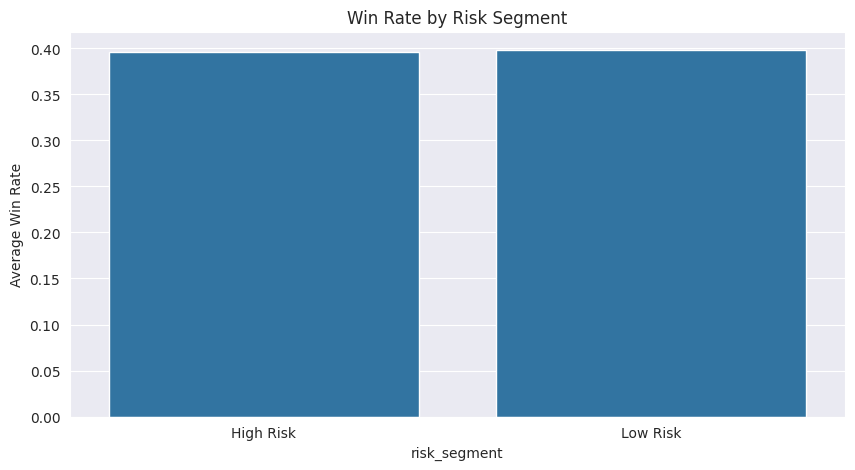

In [96]:
# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=risk_analysis,
    x='risk_segment',
    y='win_rate'
)

plt.title("Win Rate by Risk Segment")

plt.ylabel("Average Win Rate")

plt.show()

In [97]:
# Identify Consistent vs Inconsistent Traders
# Create Consistency Score
trader_summary['consistency_score'] = (
    trader_summary['win_rate'] /
    (trader_summary['pnl_std'] + 1)
)

In [98]:
# Threshold
consistency_threshold = trader_summary[
    'consistency_score'
].median()

In [99]:
# Create Segment
trader_summary['consistency_segment'] = np.where(
    trader_summary['consistency_score'] >= consistency_threshold,
    'Consistent Trader',
    'Inconsistent Trader'
)

display(trader_summary.head())

,Account,total_pnl,avg_pnl,pnl_std,avg_trade_size,avg_estimated_leverage,win_rate,activity_segment,risk_segment,consistency_score,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,533.585707,0.359612,Frequent Trader,High Risk,0.000077,Inconsistent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,134.073473,1653.226327,102.186280,0.442720,Frequent Trader,Low Risk,0.003278,Consistent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,542.182659,8893.000898,-889.448355,0.301917,Frequent Trader,Low Risk,0.000556,Inconsistent Trader
3,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,255.829091,3138.894782,303.958635,0.519914,Infrequent Trader,Low Risk,0.002024,Consistent Trader
4,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,-38.286626,558.778753,1729.941104,90.878291,0.455215,Infrequent Trader,Low Risk,0.000813,Consistent Trader


In [100]:
# Analyze Consistency Segments
consistency_analysis = trader_summary.groupby(
    'consistency_segment'
).agg({
    'total_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

display(consistency_analysis)

,consistency_segment,total_pnl,win_rate,avg_trade_size
0,Consistent Trader,253691.619864,0.411178,6815.690004
1,Inconsistent Trader,452063.218867,0.381871,6508.026104


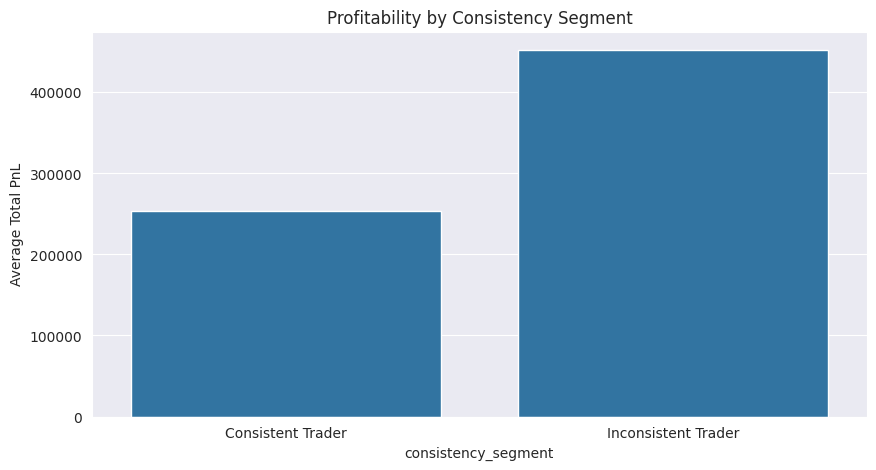

In [101]:
# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=consistency_analysis,
    x='consistency_segment',
    y='total_pnl'
)

plt.title("Profitability by Consistency Segment")

plt.ylabel("Average Total PnL")

plt.show()

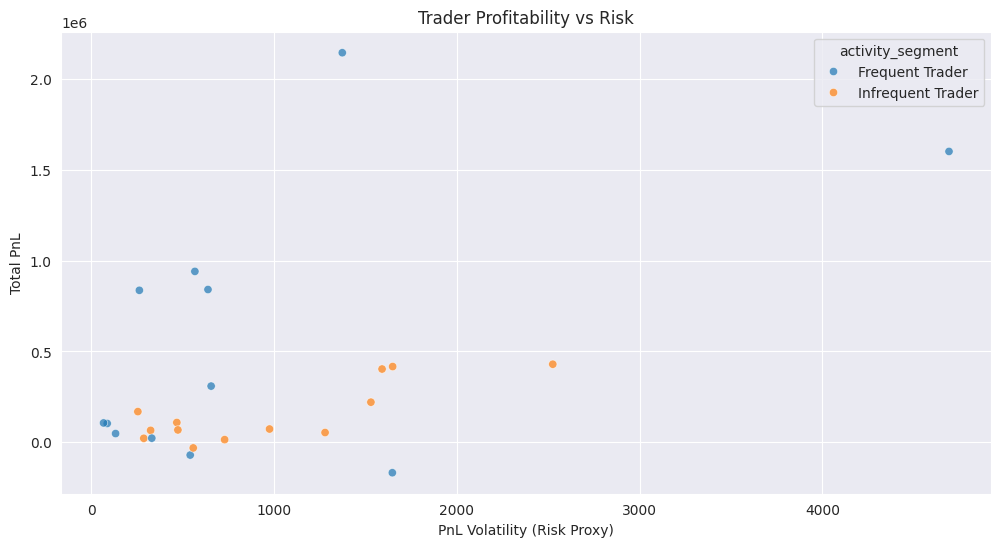

In [102]:
# Advanced Scatterplot
# Profitability vs Risk
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=trader_summary,
    x='pnl_std',
    y='total_pnl',
    hue='activity_segment',
    alpha=0.7
)

plt.title("Trader Profitability vs Risk")

plt.xlabel("PnL Volatility (Risk Proxy)")
plt.ylabel("Total PnL")

plt.show()

In [103]:
# Top Performing Traders
top_traders = trader_summary.sort_values(
    by='total_pnl',
    ascending=False
).head(10)

display(top_traders)

,Account,total_pnl,avg_pnl,pnl_std,avg_trade_size,avg_estimated_leverage,win_rate,activity_segment,risk_segment,consistency_score,consistency_segment
20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,145.481748,1374.026402,3837.885375,-501.660795,0.337134,Frequent Trader,High Risk,0.000245,Inconsistent Trader
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,16159.576734,533.585707,0.359612,Frequent Trader,High Risk,0.000077,Inconsistent Trader
22,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,44.364091,567.762763,3210.472831,16.318546,0.467582,Frequent Trader,High Risk,0.000822,Consistent Trader
10,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,68.684419,639.402444,34396.580284,3409.273074,0.401193,Frequent Trader,High Risk,0.000626,Consistent Trader
24,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,20.806305,264.123880,1844.211886,46.440225,0.428230,Frequent Trader,Low Risk,0.001615,Consistent Trader
12,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,270.034947,2525.240437,7216.667245,-28.792340,0.345912,Infrequent Trader,High Risk,0.000137,Inconsistent Trader
7,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,1649.497580,2397.824753,76.137142,0.484236,Infrequent Trader,High Risk,0.000293,Inconsistent Trader
13,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,281.826227,1591.523958,2133.667364,-0.097127,0.306294,Infrequent Trader,High Risk,0.000192,Inconsistent Trader
9,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,40.740489,656.693628,17098.171055,5595.301494,0.360364,Frequent Trader,High Risk,0.000548,Inconsistent Trader
23,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2.205191e+05,83.498320,1530.525033,7852.098338,1045.336887,0.327527,Infrequent Trader,High Risk,0.000214,Inconsistent Trader


In [104]:
# Segment Summary Table
segment_summary = trader_summary.groupby([
    'activity_segment',
    'risk_segment',
    'consistency_segment'
]).agg({
    'total_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

display(segment_summary)

,activity_segment,risk_segment,consistency_segment,total_pnl,win_rate,avg_trade_size
0,Frequent Trader,High Risk,Consistent Trader,890293.180718,0.434388,18803.526558
1,Frequent Trader,High Risk,Inconsistent Trader,971241.790651,0.359963,9825.079674
2,Frequent Trader,Low Risk,Consistent Trader,223220.193166,0.401759,5558.543593
3,Frequent Trader,Low Risk,Inconsistent Trader,-70436.191318,0.301917,8893.000898
4,Infrequent Trader,High Risk,Inconsistent Trader,230032.522160,0.405812,4271.856237
5,Infrequent Trader,Low Risk,Consistent Trader,66883.955162,0.411290,3867.366495


## Trader Segmentation & Behavioral Analysis Observations

### Trader Activity Segmentation

Traders were segmented into:
- Frequent Traders
- Infrequent Traders

using the median number of trades as the threshold.

---

### Frequent vs Infrequent Traders

The analysis revealed substantial behavioral differences between activity groups.

#### Frequent Traders
- Generated significantly higher average total PnL compared to infrequent traders.
- Maintained relatively stable win rates despite much larger trading activity.
- Exhibited greater market participation and execution consistency.

#### Infrequent Traders
- Produced considerably lower average profitability.
- Participated less actively in market opportunities.
- Demonstrated weaker overall performance efficiency.

This suggests:
- active market participation may improve profitability opportunities,
- but likely requires disciplined execution and experience.

---

### Risk-Based Segmentation

Traders were categorized into:
- High Risk Traders
- Low Risk Traders

using PnL standard deviation as a risk proxy.

---

### High Risk vs Low Risk Traders

Key findings include:

#### High Risk Traders
- Achieved slightly higher average profitability.
- Maintained win rates similar to low-risk traders.
- Took significantly larger and more volatile positions.

#### Low Risk Traders
- Displayed more stable trading behavior.
- Generated lower average profitability but reduced volatility exposure.
- Likely followed more conservative position sizing strategies.

This suggests:
- aggressive risk-taking can amplify profits,
- but also increases exposure to severe drawdowns and volatility.

---

### Consistency-Based Segmentation

A consistency score was created using:
- trader win rate
- PnL volatility

This enabled classification into:
- Consistent Traders
- Inconsistent Traders

---

### Consistent vs Inconsistent Traders

The results revealed an important behavioral pattern:

#### Inconsistent Traders
- Produced substantially higher average total PnL.
- Likely benefited from occasional extremely profitable trades.
- Displayed higher volatility and unstable performance patterns.

#### Consistent Traders
- Generated more stable but comparatively lower profitability.
- Demonstrated lower volatility exposure.
- Likely prioritized controlled execution and risk management.

This indicates that:
- large profits in crypto trading are often associated with unstable and high-volatility strategies,
- while consistency tends to favor sustainability over explosive returns.

---

### Profitability vs Risk Relationship

The profitability-risk scatterplot revealed:

- Several high-profit traders also exhibited extremely high volatility.
- Traders with lower volatility generally clustered around moderate profitability levels.
- No clear linear relationship exists between profitability and risk.

This suggests:
- profitability outcomes are highly heterogeneous,
- and trader behavior varies significantly across accounts.

The visualization also highlights the presence of:
- outlier traders,
- asymmetric returns,
- highly speculative trading behavior.

---

### Top Trader Analysis

The highest-performing traders generally exhibited:
- high trading frequency,
- elevated risk exposure,
- larger average trade sizes,
- inconsistent profitability patterns.

Many top traders belonged to:
- Frequent Trader segments
- High Risk segments

This suggests that:
- aggressive participation and larger exposure can produce outsized gains,
- though likely accompanied by substantial downside risk.

---

### Behavioral Archetypes Identified

Based on the segmentation analysis, several trader archetypes emerged:

#### 1. Aggressive High-Frequency Traders
Characteristics:
- Very active trading behavior
- High total profitability
- Elevated risk exposure
- Large trade sizes

Potential behavior:
- momentum trading
- short-term speculative execution

---

#### 2. Conservative Consistent Traders
Characteristics:
- Stable win rates
- Lower volatility
- Smaller average profits
- More controlled risk exposure

Potential behavior:
- disciplined execution
- tighter risk management

---

#### 3. Opportunistic High-Risk Traders
Characteristics:
- Highly inconsistent returns
- Large profitability spikes
- Significant volatility exposure

Potential behavior:
- leverage-heavy directional trading
- event-driven speculation

---

### Overall Segmentation Conclusion

The segmentation analysis indicates that:

- Trader behavior has a stronger relationship with profitability than market sentiment alone.
- Higher profitability is often associated with:
  - increased market activity,
  - larger trade sizes,
  - higher volatility exposure.

However:
- sustainable and consistent performance appears more closely linked to disciplined risk management rather than extreme aggressiveness.

These findings reinforce the importance of:
- behavioral profiling,
- trader discipline,
- risk-adjusted performance evaluation,
- and market psychology analysis in crypto trading environments.

### **SECTION 6 — Strategy Recommendations**

## Strategy 1 — Reduce Aggressive Exposure During Fear Markets

### Observation
The analysis revealed that:
- Fear periods contained the highest trading activity.
- Traders increased average trade sizes during Fear conditions.
- PnL volatility was substantially elevated during Fear regimes.

### Interpretation
This suggests traders become more reactive and emotionally driven during uncertain market environments.

Large position sizing during volatile Fear periods increases:
- liquidation risk,
- emotional trading,
- and unstable profitability outcomes.

### Actionable Rule
During Fear or Extreme Fear conditions:
- reduce position sizing,
- avoid excessive leverage,
- prioritize risk-managed entries,
- and avoid overtrading volatile market swings.

### Expected Benefit
This approach may help:
- reduce drawdowns,
- improve long-term consistency,
- and prevent emotionally driven losses.

## Strategy 2 — Momentum-Based Trading Performs Better During Greed Regimes

### Observation
The analysis showed:
- Extreme Greed periods produced the highest trader win rates.
- Greed markets demonstrated stronger directional participation.
- Frequent traders generally achieved higher profitability.

### Interpretation
Bullish sentiment environments may create:
- stronger momentum continuation,
- higher market participation,
- and cleaner short-term trading opportunities.

### Actionable Rule
During Greed or Extreme Greed conditions:
- momentum-based strategies may perform better,
- active traders may benefit from increased participation,
- and short-term trend-following setups may become more effective.

However:
- strict stop-loss management remains critical due to volatility spikes.

### Expected Benefit
This strategy may improve:
- short-term win rates,
- trade opportunity frequency,
- and directional execution efficiency.

## Strategy 3 — Consistency Outperforms Extreme Risk-Taking Over Time

### Observation
The segmentation analysis revealed:
- Highly profitable traders often displayed unstable and high-volatility behavior.
- Consistent traders generated lower but more stable profitability.
- Risk exposure strongly influenced profitability variability.

### Interpretation
Aggressive trading strategies can produce large gains, but often expose traders to:
- significant drawdowns,
- unstable performance,
- and unsustainable risk profiles.

### Actionable Rule
Traders should prioritize:
- stable execution,
- controlled risk exposure,
- disciplined position sizing,
- and long-term consistency rather than maximizing short-term profits.

### Expected Benefit
This approach may improve:
- sustainability,
- risk-adjusted returns,
- and long-term trading survivability.

### **SECTION 7 — Final Conclusion**

## Project Summary

This project analyzed the relationship between Bitcoin market sentiment and trader behavior on Hyperliquid using over 211,000 trade records combined with Fear & Greed market sentiment data.

The analysis explored:
- trader profitability,
- trading activity,
- position sizing,
- directional behavior,
- and behavioral segmentation across different market sentiment regimes.

---

## Key Findings

### Market Sentiment Influences Trader Behavior
Fear and Greed conditions produced meaningful behavioral differences in:
- trading frequency,
- position sizing,
- directional participation,
- and risk-taking behavior.

---

### Behavioral Factors Matter More Than Sentiment Alone
While profitability differences between Fear and Greed periods were not strongly statistically significant, trader behavior patterns showed stronger explanatory power.

Factors such as:
- trading frequency,
- volatility exposure,
- consistency,
- and position sizing

were more closely associated with profitability outcomes.

---

### High Profitability Often Correlates With Higher Risk
Many top-performing traders demonstrated:
- elevated volatility,
- aggressive trading behavior,
- and inconsistent return patterns.

This suggests that large profits in crypto trading are frequently accompanied by substantial downside risk.

---

### Consistency and Risk Management Remain Critical
More stable traders generally exhibited:
- lower volatility,
- disciplined participation,
- and more sustainable behavior patterns.

This reinforces the importance of:
- risk management,
- controlled leverage,
- and behavioral discipline in volatile crypto markets.

---

## Final Takeaway

The study demonstrates that:
- market sentiment shapes trader psychology,
- trader psychology influences behavior,
- and behavior ultimately impacts trading performance.

Successful trading appears to depend less on sentiment direction itself and more on how traders adapt their:
- risk management,
- participation intensity,
- and execution discipline across changing market conditions.

### **SECTION 8 — Future Improvements**

# SECTION 8 — Future Improvements

Future enhancements for this project could include:

- Incorporating explicit leverage data if available
- Building predictive machine learning models for trader profitability
- Performing time-series sentiment forecasting
- Applying clustering algorithms for advanced trader archetype discovery
- Developing a Streamlit dashboard for interactive analysis
- Adding portfolio-level risk metrics and drawdown analysis
- Integrating additional market indicators such as volatility and funding rates

These additions could further improve behavioral understanding and predictive trading analytics.